# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from section_loads import *

DATA = ROOT / "data"
OUT = ROOT / "outputs"
IMAGES = OUT / "images"
OUT.mkdir(exist_ok=True)

In [3]:
# Which end of each component to accumulate from. "low" starts at the lowest
# station coordinate, "high" at the highest.
# lh=high, rh=low
STATION_FROM = {"vehicle": "low",
                "fuselage": "low", 
                "wing lh": "high",
                "wing rh": "low",
                "tail lh": "high",
                "tail rh": "low",
                "tail lower": "low"}

In [4]:
VEHICLE = "vehicle"                    # its sections bin every body node
EXCLUDE_ITEMS = {"point masses"}       # node_ranges items kept out of sections
VEHICLE_CG = np.array([149, 0.0, 100])
INERTIA_SIGN = -1.0
ACCEL_TO_G = 1.0
# ONLY_LOADCASES = ["100245", "10110002"]
ONLY_LOADCASES = None

# Body Load Processing

In [5]:
sections, node_ranges, load_cases, point_masses = read_tables(DATA)
df, load_cases = read_force_cards(DATA, load_cases, only=ONLY_LOADCASES)
display(load_cases)

df, excluded = apply_exclusions(df, load_cases)
display(excluded)

,loadcase,configuration,nx,ny,nz,case_description,exclude_nodes,config
0,LC100245,FF,0.019043,0.0,4.500000,FF 1,"{90000013, 46270}",FF
1,LC100490,FF,0.003390,0.0,-3.000000,FF 2,"{90000013, 46270}",FF
2,LC200023,FF,-0.011144,0.0,1.000000,FF 3,"{90000013, 46270}",FF
3,LC200245,FF,0.015755,0.0,4.500000,FF 4,"{90000013, 46270}",FF
4,LC200420,FF,0.002058,0.0,4.460931,FF 5,"{90000013, 46270}",FF
...,...,...,...,...,...,...,...,...
56,LC11032471,CC,-1.500000,2.2,-1.000000,CC F16 28,{},CC
57,LC11032486,CC,-1.500000,-2.2,-1.000000,CC F16 29,{},CC
58,LC11032510,CC,1.500000,2.2,-1.000000,CC F16 30,{},CC
59,LC11032516,CC,-1.500000,-2.2,-1.000000,CC F16 31,{},CC


,loadcase,declared,rows_removed,nodes_removed,not_present
0,LC100245,2,0,0,2
1,LC100490,2,0,0,2
2,LC10110002,2,0,0,2
3,LC10110008,2,0,0,2
4,LC10110013,2,0,0,2
...,...,...,...,...,...
56,LC500390,0,0,0,0
57,LC506271,0,0,0,0
58,LC507173,0,0,0,0
59,LC507174,0,0,0,0


In [6]:
check_component_coverage(sections, node_ranges, VEHICLE, EXCLUDE_ITEMS)
check_configurations(sections, load_cases)
 
pd.concat([
    check_card_configurations(df, load_cases),
    check_sections_per_configuration(sections, node_ranges, load_cases,
                                     VEHICLE, EXCLUDE_ITEMS),
])

,loadcase,from_folder,from_csv,agree
0,LC10110002,CC,CC,True
1,LC10110008,CC,CC,True
2,LC10110013,CC,CC,True
3,LC10120002,CC,CC,True
4,LC10120008,CC,CC,True
...,...,...,...,...
56,LC500390,FF,FF,True
57,LC506271,FF,FF,True
58,LC507173,FF,FF,True
59,LC507174,FF,FF,True


In [7]:
df = tag_components(df, node_ranges, EXCLUDE_ITEMS)
node_report(df)

,component,nodes,excluded,in_sections
0,fuselage,82345,0,82345
1,point masses,20,20,0
2,tail lh,2030,0,2030
3,tail lower,1163,0,1163
4,tail rh,2015,0,2015
5,wing lh,7060,0,7060
6,wing rh,7156,0,7156


In [8]:
pm_loads = point_mass_loads(point_masses, load_cases, INERTIA_SIGN, ACCEL_TO_G)
sec, bodies = run_sections(df, sections, load_cases, VEHICLE)
assignment_report(bodies, sections, VEHICLE)

,configuration,partition,component,sta_dir,sections,nodes,assigned,orphans,gaps
0,CC,component,fuselage,X,10,82345,82345,0,0
1,CC,component,tail lh,Y,4,2030,2030,0,0
2,CC,component,tail lower,Z,4,1163,1163,0,0
3,CC,component,tail rh,Y,4,2015,2015,0,0
4,CC,component,wing lh,X,6,6753,6753,0,0
5,CC,component,wing rh,X,6,6849,6849,0,0
6,CC,vehicle,vehicle,X,10,101155,101155,0,0
7,FF,component,fuselage,X,10,82345,82345,0,0
8,FF,component,tail lh,Y,4,2030,2030,0,0
9,FF,component,tail lower,Z,4,1163,1163,0,0


In [9]:
agree = check_partitions_agree(sec, VEHICLE_CG)
audit = force_audit(df, pm_loads, VEHICLE_CG, sec)
display(audit)

,loadcase,group,rows,Fx,Fy,Fz,Mx,My,Mz
0,LC100245,1 all card rows,101788,0.007807,0.003207,-0.003723,0.358254,-183.507846,287.810571
1,LC100245,2 held-out item rows,19,-1.246190,0.000000,-294.429700,-115.655895,924.721430,0.464153
2,LC100245,3 card rows in sections,101769,1.253997,0.003207,294.425977,116.014150,-1108.229276,287.346418
3,LC100245,3a component sections,34,1.253997,0.003207,294.425977,116.014150,-1108.229276,287.346418
4,LC100245,4 point mass loads,13,-1.452242,0.000000,-343.174231,-45.079023,-115.457471,0.190765
...,...,...,...,...,...,...,...,...,...
361,LC507529,2 held-out item rows,20,-0.291650,44.031290,-95.428630,-31.096699,432.358457,199.592134
362,LC507529,3 card rows in sections,101769,0.296909,-44.031970,95.428505,36.563760,-513.187387,-107.447469
363,LC507529,3a component sections,34,0.296909,-44.031970,95.428505,36.563760,-513.187387,-107.447469
364,LC507529,4 point mass loads,14,-0.324756,49.029675,-106.260940,-6.873297,92.399919,42.655092


In [10]:
cg_breakdown(sec, pm_loads, VEHICLE_CG)

,loadcase,partition,level,component,section_id,label,sta_lo,sta_hi,n_nodes,Fx,Fy,Fz,Mx,My,Mz
0,LC100245,component,section,fuselage,30000001,Nosecone,100.745,103.97,2123.0,22.566602,1.228247,-14.754814,1.372928,-644.424004,-53.067382
1,LC100245,component,section,fuselage,30000002,Fwd Body 1,103.970,113.97,7197.0,-4.538365,-6.188290,-25.774805,-1.132290,-991.070454,237.898890
2,LC100245,component,section,fuselage,30000003,Fwd Body 2,113.970,123.97,6377.0,-16.595902,3.005666,-55.063200,-0.782986,-1611.174271,-93.132946
3,LC100245,component,section,fuselage,30000004,Mid Body 1,123.970,133.97,15185.0,-0.182723,-1.273900,-50.591907,-16.671730,-1042.103148,30.883858
4,LC100245,component,section,fuselage,30000005,Mid Body 2,133.970,143.97,16327.0,-0.172903,-0.862213,-39.697750,-10.649310,-407.036041,6.192346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3350,LC507529,vehicle,section,vehicle,9,Aft Body 2,173.970,183.97,3883.0,4.679052,-11.841579,-12.631813,157.377643,370.657161,-411.669129
3351,LC507529,vehicle,section,vehicle,10,Aft Body 3,183.970,195.00,7209.0,-3.781311,-29.795553,-12.572655,803.693176,495.066147,-1063.804780
3352,LC507529,vehicle,subtotal,vehicle,<NA>,vehicle total,NaN,NaN,101769.0,0.296909,-44.031970,95.428505,36.563760,-513.187387,-107.447469
3353,LC507529,vehicle,point masses,,<NA>,,NaN,NaN,NaN,-0.324756,49.029675,-106.260940,-6.873297,92.399919,42.655092


In [11]:
export_section_loads(sec, OUT / "section_loads.csv")
export_point_mass_loads(pm_loads, OUT / "point_mass_loads.csv")
pd.DataFrame({"file": sorted(p.name for p in OUT.glob("*.csv"))})

,file
0,point_mass_loads.csv
1,section_loads.csv


# Station Envelopes

In [12]:
diag = station_diagram(sec, direction=STATION_FROM)
station_drivers(diag)

,partition,component,configuration,quantity,axis,peak,station,loadcase
0,component,fuselage,ALL,Fx,normal,638.705033,190.000000,LC14010019
1,component,fuselage,ALL,Fy,lateral 1,-683.954589,190.000000,LC11016074
2,component,fuselage,ALL,Fz,lateral 2,-1455.291362,190.000000,LC11014030
3,component,fuselage,ALL,Mx,normal,-222.267408,173.970000,LC11013972
4,component,fuselage,ALL,My,lateral 1,-69033.396999,190.000000,LC11014030
5,component,fuselage,ALL,Mz,lateral 2,-32801.871023,190.000000,LC11016029
6,component,tail lh,ALL,Fy,normal,72.577093,-14.500000,LC11016094
7,component,tail lh,ALL,Fz,lateral 1,135.134931,-14.500000,LC11025338
8,component,tail lh,ALL,Fx,lateral 2,15.345007,-14.500000,LC10110013
9,component,tail lh,ALL,My,normal,96.998327,-9.633333,LC11026355


{('fuselage', 'ALL'): <Figure size 1500x700 with 6 Axes>,
 ('tail lh', 'ALL'): <Figure size 1500x700 with 6 Axes>,
 ('tail lower', 'ALL'): <Figure size 1500x700 with 6 Axes>,
 ('tail rh', 'ALL'): <Figure size 1500x700 with 6 Axes>,
 ('wing lh', 'CC'): <Figure size 1500x700 with 6 Axes>,
 ('wing lh', 'FF'): <Figure size 1500x700 with 6 Axes>,
 ('wing rh', 'CC'): <Figure size 1500x700 with 6 Axes>,
 ('wing rh', 'FF'): <Figure size 1500x700 with 6 Axes>}

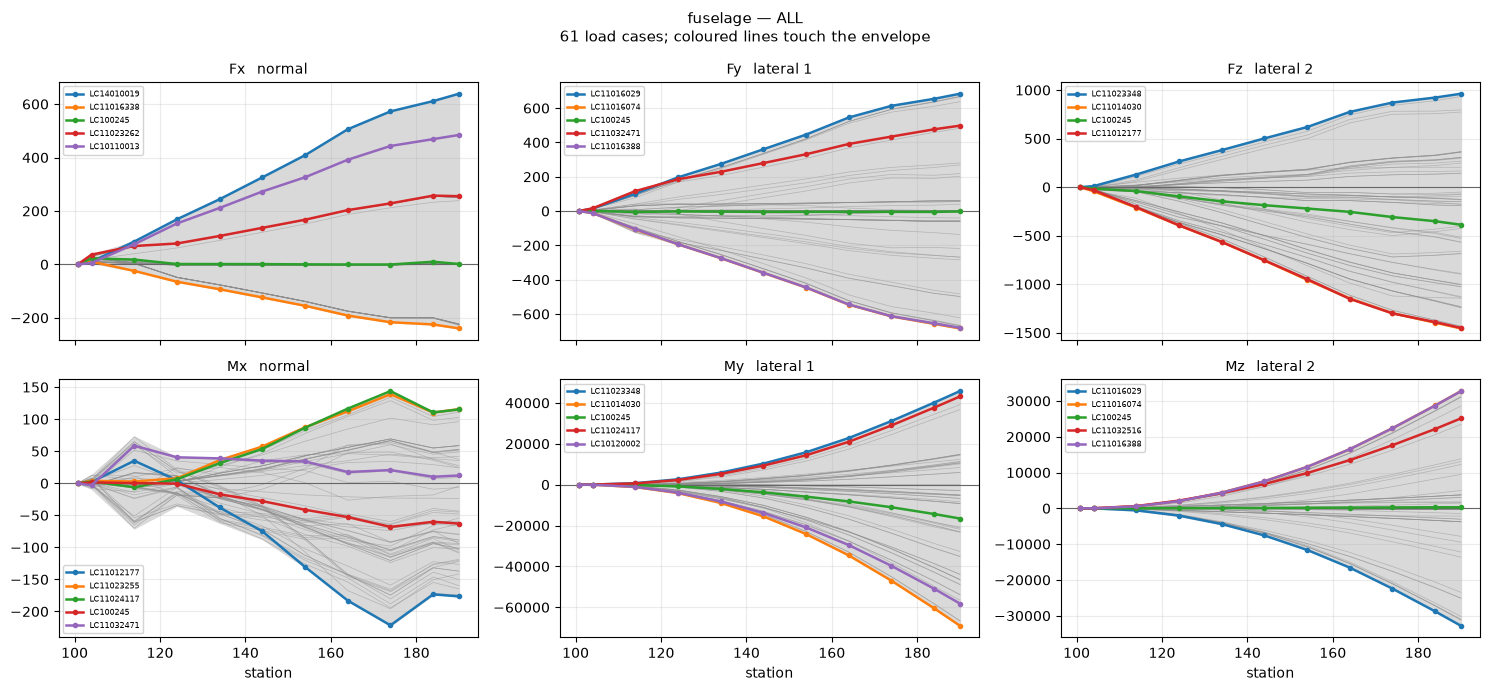

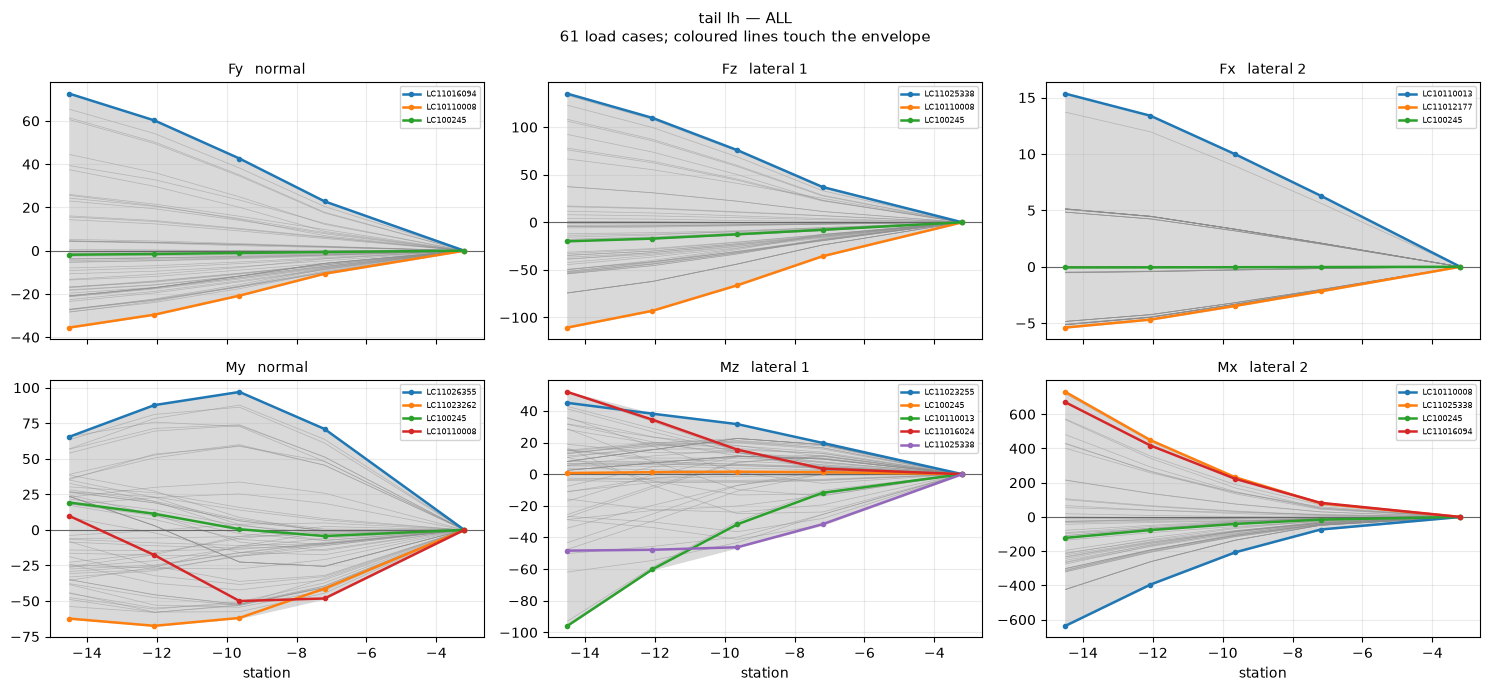

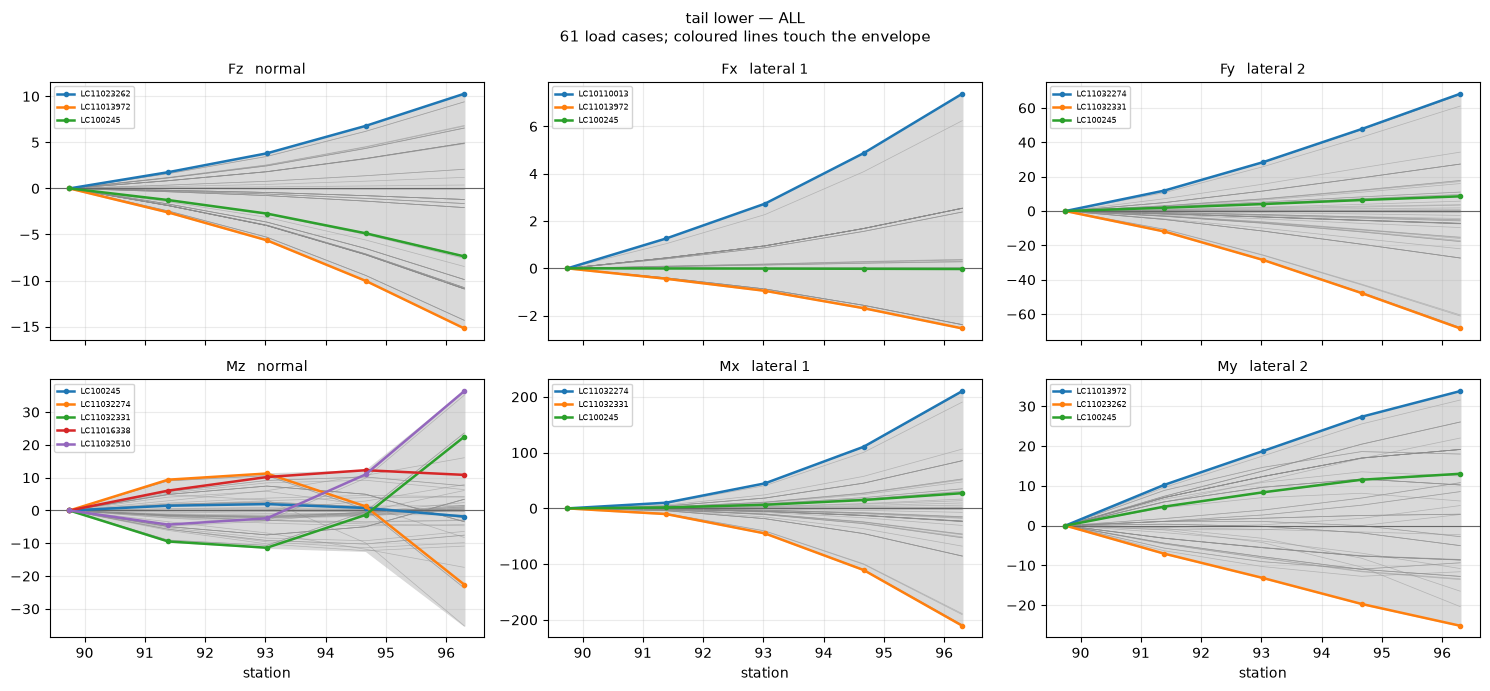

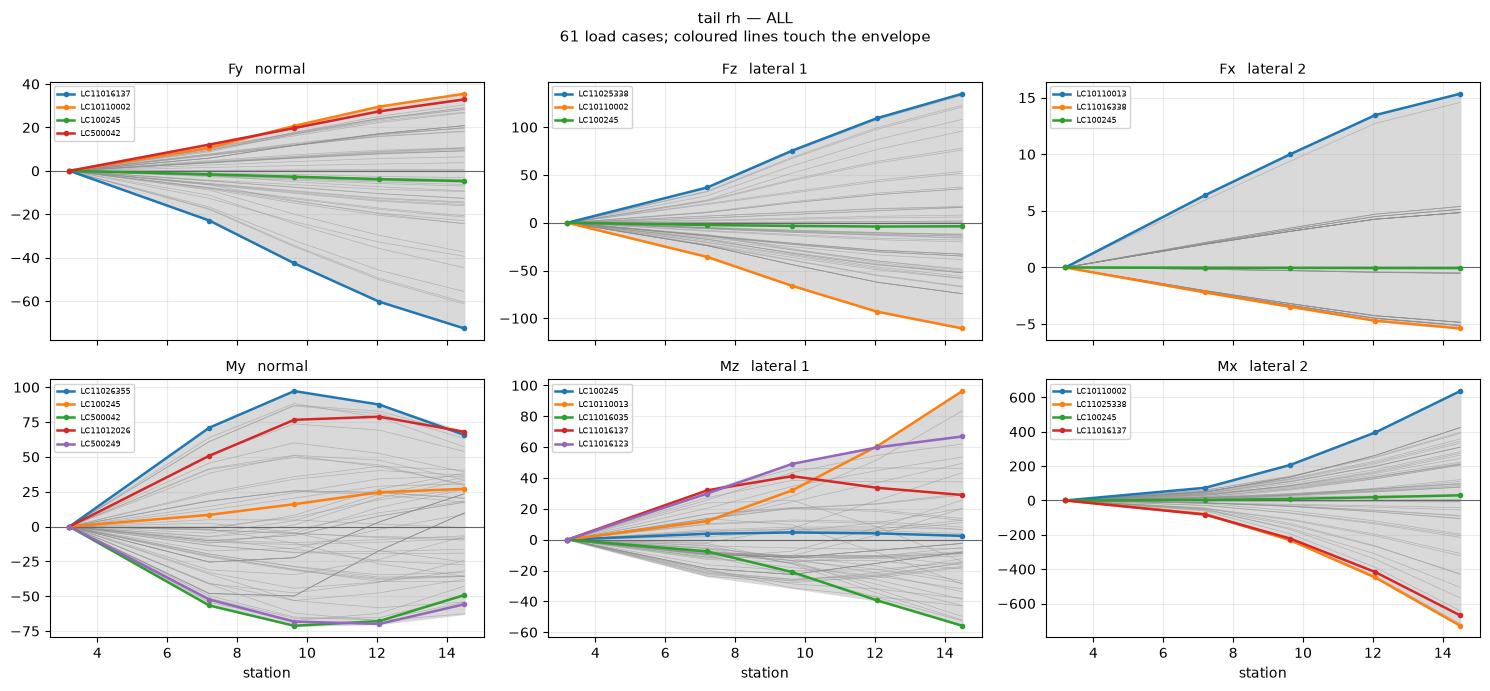

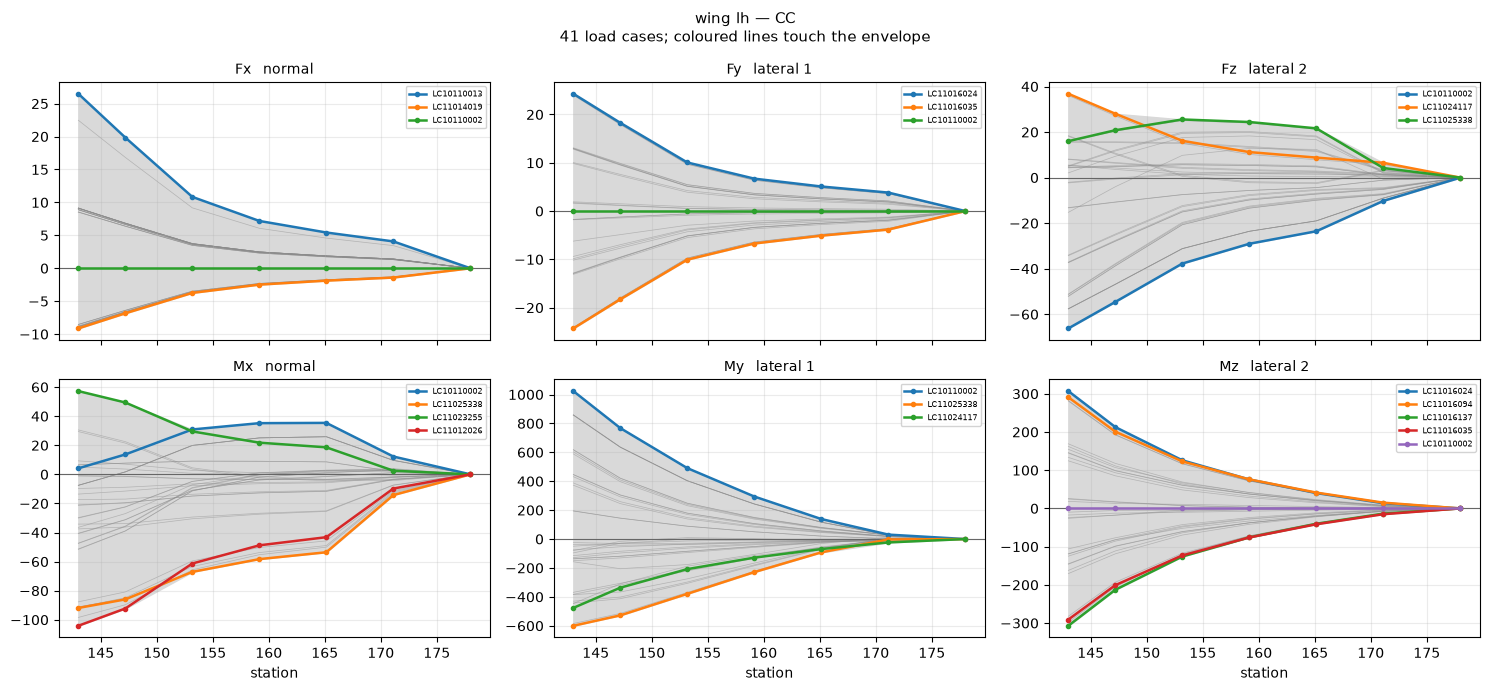

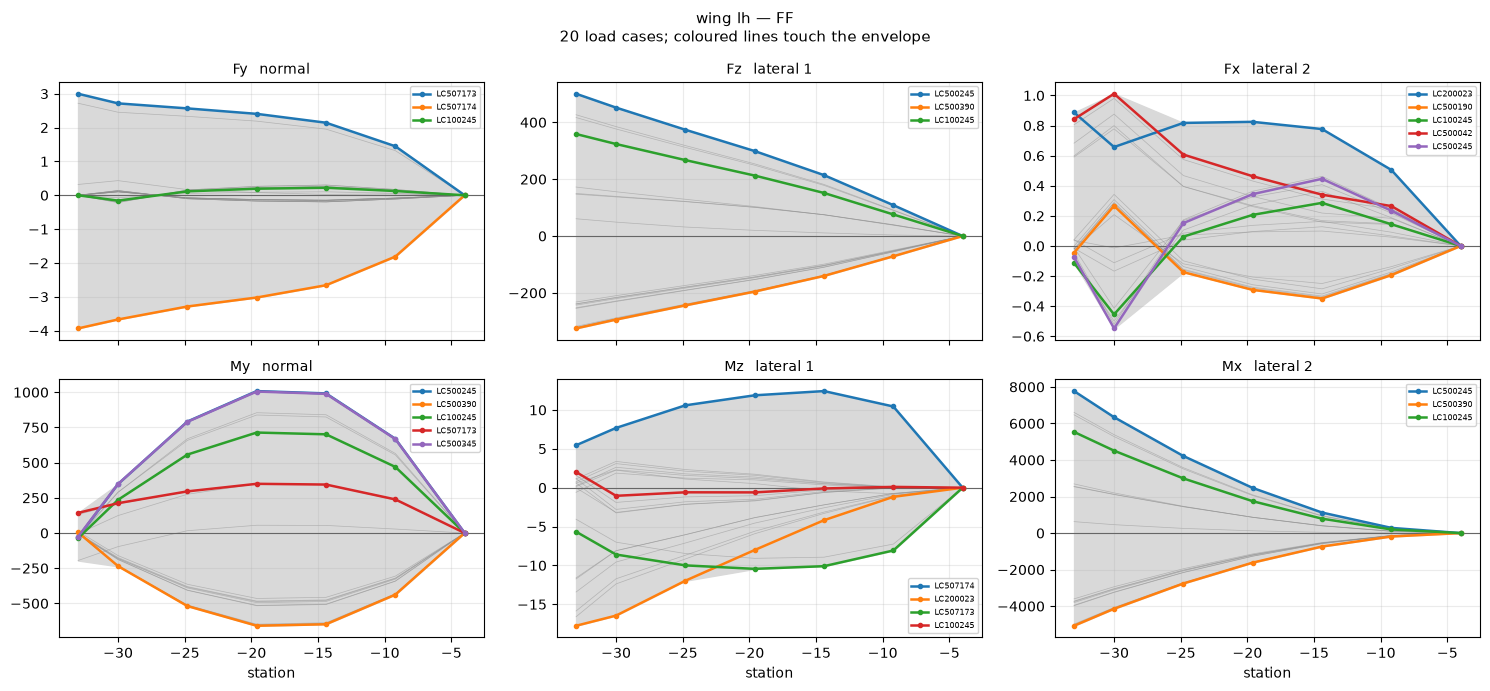

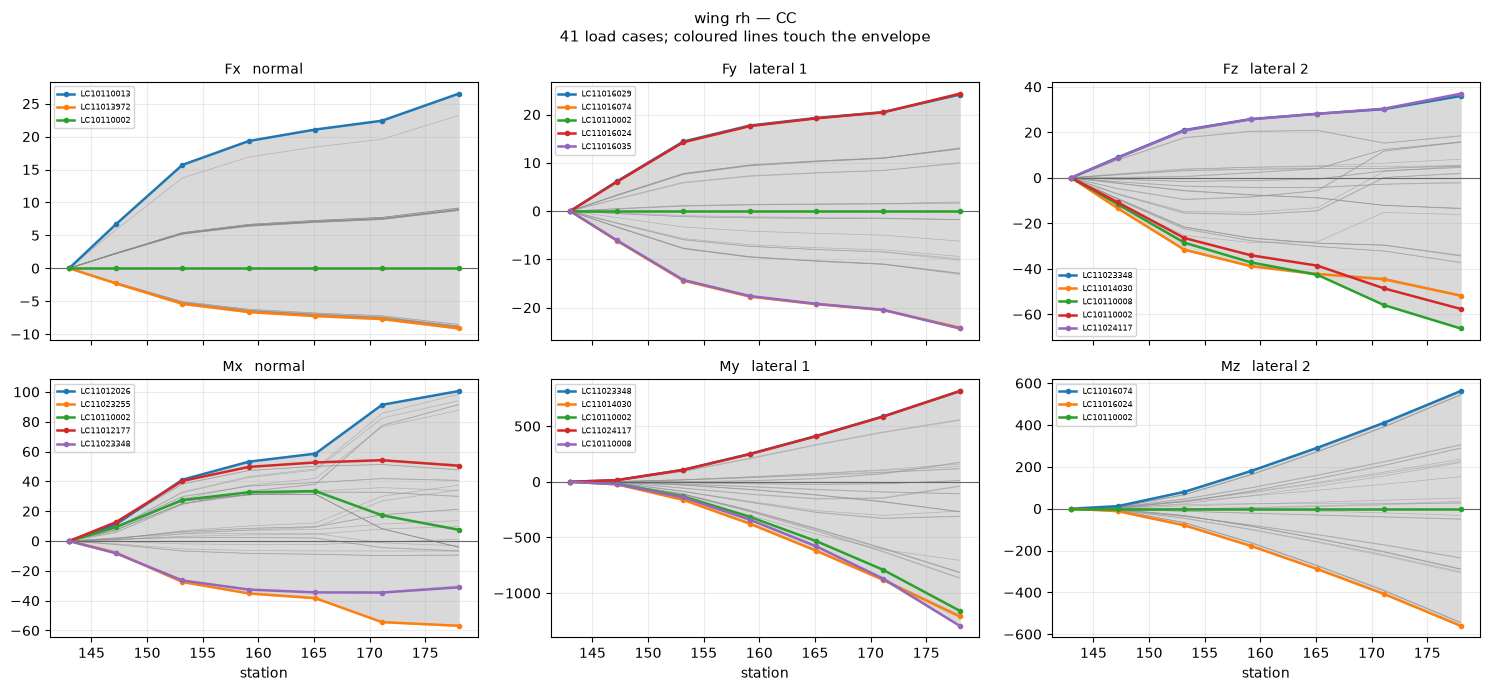

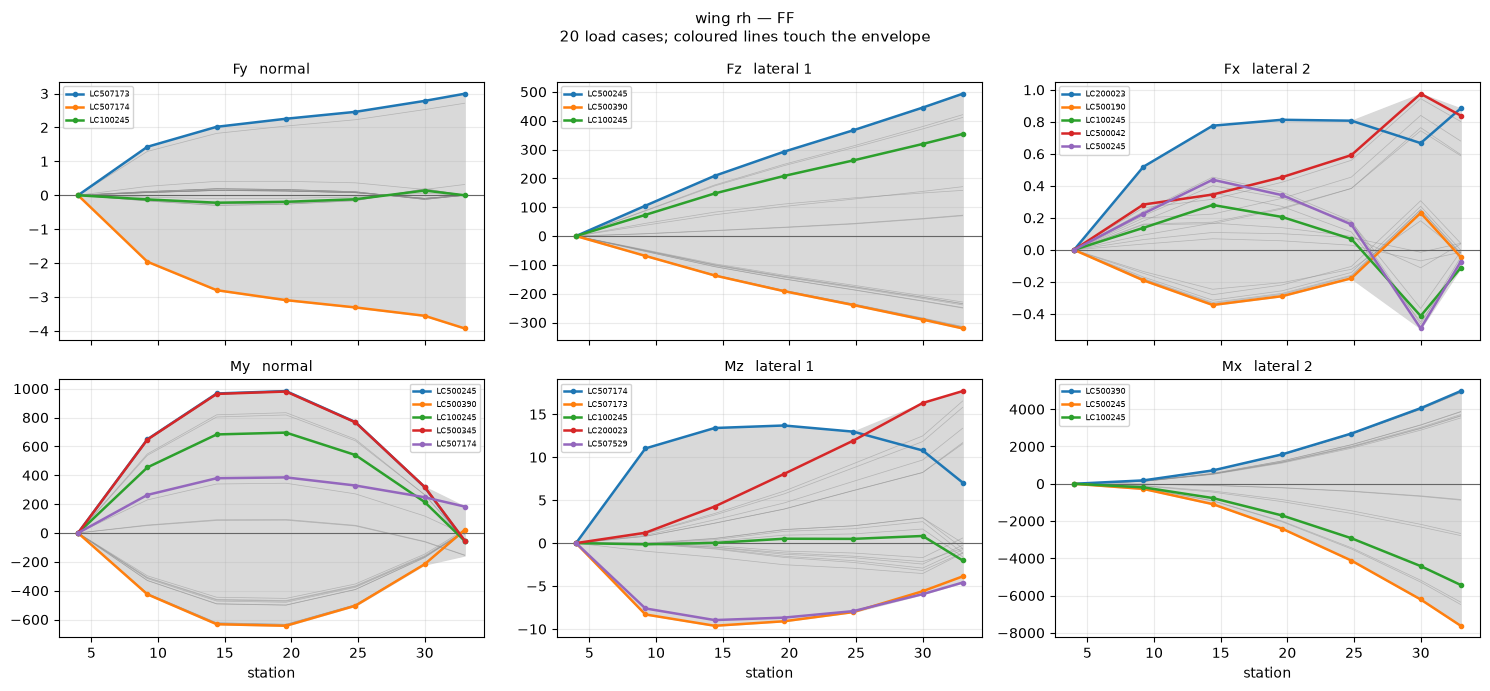

In [13]:
# plot_all_station_diagrams(diag, out_dir=IMAGES)
plot_all_station_diagrams(diag, out_dir=IMAGES, drivers=5)   # cap the list
# plot_all_station_diagrams(diag, out_dir=IMAGES, envelope=False)